# Parallel Random Circuit Sampling (RCS) & XEB Analysis

This notebook demonstrates the `RCSExperiment` and `RCSResults` framework for generating, executing, and analyzing Random Circuit Sampling experiments.

In [ ]:
# To run this notebook in Google Colab, uncomment and run the following line:
#!pip install cirq cirq_google qsimcirq

# To install the local 'recirq' package from the repository:
# 1. Clone the repo: !git clone https://github.com/quantumlib/ReCirq.git
# 2. Install: !pip install -e ReCirq/
# 3. IMPORTANT: Restart the Colab runtime (Runtime > Restart session) after installation.

#Imports

In [5]:
import cirq
import cirq_google
import qsimcirq
import recirq.random_circuit_sampling as rcs
import matplotlib.pyplot as plt
import numpy as np

# Define the patches

Select sets of connected qubits to serve as patches. These patches must be disjoint and should not share any common qubits.

In [6]:
patch_1 = cirq.GridQubit.rect(4, 3, top=0, left=0)
patch_2 = cirq.GridQubit.rect(4, 3, top=0, left=3)
patch_3 = cirq.GridQubit.rect(4, 3, top=4, left=0)
patches = [patch_1, patch_2, patch_3]

# Set up and run the experiment

Specify the qubit patches and the desired circuit depths for XEB calculation. Additionally, define the number of random circuit instances per configuration and the specific tiling pattern for the experiment. While the framework supports characterizing the $fSim$ gate parameters ($\theta, \phi, \zeta, \chi, \gamma$), this step is bypassed here as we are performing an ideal noiseless simulation.

In [7]:
experiment = rcs.RCSExperiment(
    patches=patches,
    depths=[30, 50, 70, 90],
    num_instances=3,
    pattern_name="staggered",
    seed= 2026
)

In [8]:
results = experiment.run(sampler=cirq.Simulator(), n_repetitions=10000, characterize=False)

Running 12 zipped instances on 3 parallel patches...


# Calculate linear XEB fidelities

To calculate fidelities via noiseless simulation, we can employ the standard `cirq.Simulator()`. Here, we use the performance-optimized `qsimcirq.QSimSimulator()` to improve execution efficiency.


In [9]:
fidelities = results.fidelities_lin(simulator=qsimcirq.QSimSimulator())

XEB Analysis: 100%|█████████████████████████████████████████████████████████████| 36/36 [00:01<00:00, 21.72it/s]


# Plot the results

Visualize the XEB results for each patch across the specified circuit depths. The plot reflects the mean fidelity calculated across all random circuit instances for each (patch, depth) configuration.

Note on ideal vs. noisy simulation: You might notice that the plotted linear XEB fidelity is flat at around 1.0 across all circuit depths. This behavior is exactly what we expect from an ideal, noiseless simulation. In a real quantum hardware experiment (or a noisy simulation), incoherent errors and decoherence accumulate at each gate layer, resulting in a characteristic exponential decay curve as the circuit gets deeper. Since our simulated qubits do not suffer from any noise, the fidelity remains at ~1.0 (with microscopic fluctuations resulting purely from finite sampling variance across our 10,000 repetitions). See the next section for noisy simulation.

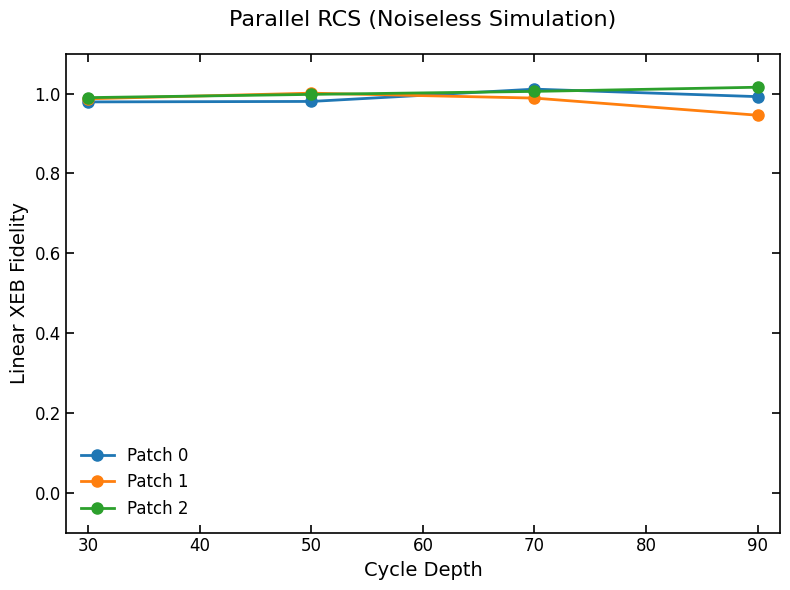

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(patches)):
    x = experiment.depths
    y = [np.mean(fidelities[(i, d)]) for d in x]
    ax.plot(x, y, marker='o', markersize=8, linewidth=2, label=f'Patch {i}')

ax.set_ylim(-0.1, 1.1)
ax.set_xlim(min(experiment.depths) - 2, max(experiment.depths) + 2)
ax.set_xlabel('Cycle Depth', fontsize=14)
ax.set_ylabel('Linear XEB Fidelity', fontsize=14)
ax.set_title('Parallel RCS (Noiseless Simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()

# Noisy simulation with quantum virtual machines

We perform noisy simulations using the [Quantum Virtual Machine (QVM)](https://quantumai.google/cirq/simulate/quantum_virtual_machine) to account for device-specific connectivity and calibration-based noise profiles. The resulting XEB fidelity plot demonstrates the fidelity decay as circuit depth increases, reflecting the accumulation of errors in a noisy system.

In [11]:
processor_id = "weber"
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
sim = cirq.DensityMatrixSimulator(noise=noise_model)

In [12]:
device = cirq_google.engine.create_device_from_processor_id(processor_id)
cal = cirq_google.engine.load_median_device_calibration(processor_id)
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
qvm_sampler = sim_engine.get_sampler(processor_id)
print(sim_engine.get_processor(processor_id).get_device())

                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                                    (2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                                    │        │        │        │        │
                                    │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)───(4, 5)───(4, 6)───(4, 7)───(4, 8)───(4, 9)
         │        │        │        │        │        │   

In [13]:
patch_1_on_device = [
    cirq.GridQubit(4, 1), cirq.GridQubit(4, 2), cirq.GridQubit(4, 3),
    cirq.GridQubit(5, 1), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3),
    cirq.GridQubit(6, 1), cirq.GridQubit(6, 2), cirq.GridQubit(6, 3)
]

patch_2_on_device = [
    cirq.GridQubit(1, 4), cirq.GridQubit(1, 5), cirq.GridQubit(1, 6),
    cirq.GridQubit(2, 4), cirq.GridQubit(2, 5), cirq.GridQubit(2, 6),
    cirq.GridQubit(3, 4), cirq.GridQubit(3, 5), cirq.GridQubit(3, 6)
]

patch_3_on_device = [
    cirq.GridQubit(4, 4), cirq.GridQubit(4, 5), cirq.GridQubit(4, 6),
    cirq.GridQubit(5, 4), cirq.GridQubit(5, 5), cirq.GridQubit(5, 6),
    cirq.GridQubit(6, 4), cirq.GridQubit(6, 5), cirq.GridQubit(6, 6)
]

patches_on_device = [patch_1_on_device, patch_2_on_device, patch_3_on_device]

In [14]:
noisy_experiment = rcs.RCSExperiment(
    patches=patches_on_device,
    depths=[10, 30, 50, 70, 90],
    num_instances=3,
    pattern_name="staggered",
    seed= 2026
)

In [15]:
noisy_results = noisy_experiment.run(
    sampler=qvm_sampler,
    n_repetitions=10000
)

noisy_fidelities = noisy_results.fidelities_lin()

Running 15 zipped instances on 3 parallel patches...


XEB Analysis: 100%|█████████████████████████████████████████████████████████████| 45/45 [00:04<00:00, 10.24it/s]


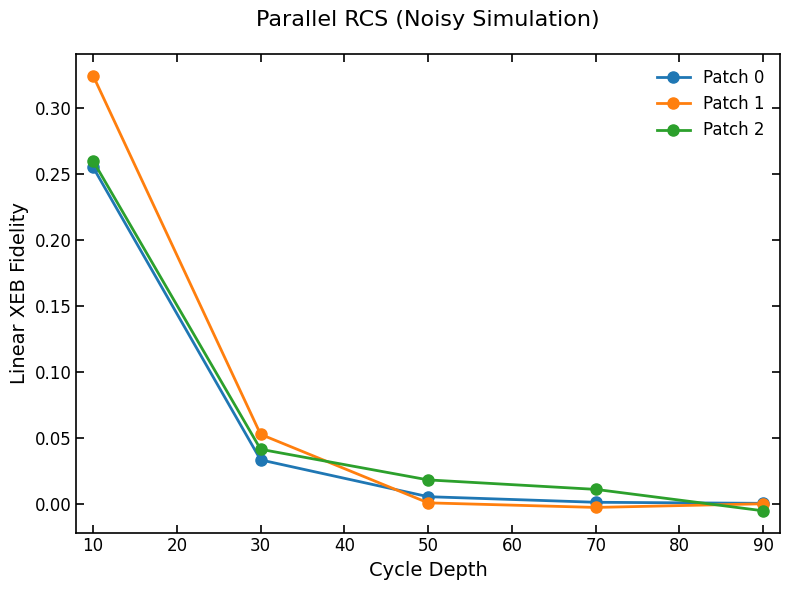

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(patches_on_device)):
    x = noisy_experiment.depths
    y = [np.mean(noisy_fidelities[(i, d)]) for d in x]
    ax.plot(x, y, marker='o', markersize=8, linewidth=2, label=f'Patch {i}')


ax.set_xlim(min(noisy_experiment.depths) - 2, max(noisy_experiment.depths) + 2)
ax.set_xlabel('Cycle Depth', fontsize=14)
ax.set_ylabel('Linear XEB Fidelity', fontsize=14)
ax.set_title('Parallel RCS (Noisy Simulation)', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()